(example_combatgam_in_mareos)=

# Benchmark NeuroComBat in MAREoS dataset


In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

from uniharmony import verbosity
from uniharmony.combat import ComBatGAM
from uniharmony.datasets import load_MAREoS


sns.set_theme(style="whitegrid")
verbosity("debug")
warnings.filterwarnings(action="ignore", category=ConvergenceWarning)

/opt/hostedtoolcache/Python/3.14.4/x64/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) Load MAREoS benchmark dataset
- `datasets = load_MAREoS()` loads simulated neuroimaging benchmark data.
- The dataset contains multiple scenarios (`true` vs `eos` effects; `simple` vs `interaction`; example 1/2).

In [2]:
# Load the MAREoS dataset (made for benchmarking harmonization methods)
datasets = load_MAREoS()

# Define the different effects, effect types, and examples to iterate over
effects = ["true", "eos"]
effect_types = ["simple", "interaction"]
effect_examples = ["1", "2"]

random_state = 23

# Assign an empty list to each key in the results dictionary
unharmonized_results = []
neurocombat_results = []

# Define the harmonization model to use (NeuroComBat in this case)
harm_model = ComBatGAM()

2026-04-30 09:30:54 [info     ] MAREoS datasets already exist at: /home/runner/.cache/uniharmony/MAREoS


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/eos_simple1_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/eos_simple2_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/eos_interaction1_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/eos_interaction2_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/true_simple1_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/true_simple2_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/true_interaction1_data.csv


2026-04-30 09:30:54 [info     ] Getting data file: /home/runner/.cache/uniharmony/MAREoS/public_datasets/true_interaction2_data.csv


## 3) Experiment loop
- Iterates all combinations:
    - `effect` = `true` or `eos`
    - `effect_type` = `simple` or `interaction`
    - `example` = `1` or `2`
- For each combination:
    - Choose classifier: logistic regression for simple; random forest for interaction.
    - Extract data: `X`, `y`, `sites`, `folds`.
    - Do leave-one-fold-out cross-validation:
        - train on folds != current fold
        - test on fold == current fold
    - Train baseline classifier on unharmonized training data and compute balanced accuracy on raw test.
    - Harmonize training with `NeuroComBat.fit_transform(...)`, then train classifier, transform test, compute balanced accuracy.
- Collect results into two lists and then into DataFrames.

In [3]:
for effect in effects:
    for e_types in effect_types:
        if e_types == "interaction":
            clf = RandomForestClassifier(n_estimators=10, random_state=random_state)
        elif e_types == "simple":
            clf = LogisticRegression(random_state=random_state)
        for e_example in effect_examples:
            example = effect + "_" + e_types + e_example
            print(f"Running experiment: {example}")
            data = datasets[example]

            sites = data["sites"]
            X = data["X"]
            folds = data["folds"]
            folds = pd.Series(folds)
            sites = data["sites"]

            target = data["y"]

            covars = target.ravel().reshape(-1, 1)

            for fold in folds.unique():
                # Train Data
                X = data["X"].copy()
                y = data["y"].copy()
                sites = data["sites"].copy()

                # Train Target
                X_train = X[data["folds"] != fold]
                site_train = sites[data["folds"] != fold]

                y_train = y[data["folds"] != fold]

                # Test data
                X_test = X[data["folds"] == fold]
                site_test = sites[data["folds"] == fold]

                # Test target
                y_test = y[data["folds"] == fold]

                # Unharmonized baseline model
                clf.fit(X_train, y_train)
                unharmonized_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=X_test)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

                # neuroComBat (do not include target as covariate - avoiding data leakage)
                X_train_harm = harm_model.fit_transform(X=X_train, sites=site_train, smooth_covariates=y_train.reshape(-1, 1))
                # Fit the model with the harmonized train
                clf.fit(X_train_harm, y_train)
                # harmonize the test data
                X_test_harm = harm_model.transform(X=X_test, sites=site_test, smooth_covariates=y_test.reshape(-1, 1))

                neurocombat_results.append(
                    [
                        balanced_accuracy_score(y_true=y_test, y_pred=clf.predict(X=X_test_harm)),
                        fold,
                        effect,
                        e_types,
                        e_example,
                        example,
                    ]
                )

# Results to datadframe
unharmonized_results = pd.DataFrame(data=unharmonized_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
unharmonized_results["Method"] = "Unharmonized Baseline"

neurocombat_results = pd.DataFrame(data=neurocombat_results, columns=["bACC", "Fold", "Effect", "Type", "Example", "Name"])
neurocombat_results["Method"] = "ComBatGAM"

results = pd.concat([unharmonized_results, neurocombat_results])

Running experiment: true_simple1
2026-04-30 09:30:54 [debug    ] Fitting                       


2026-04-30 09:30:54 [info     ] If you intend to build a machine learning (ML) model,then make sure that you DO *NOT* preserve the ML model's target as covariate. You will be required to provide the covariate also at transform time, and this will produce data leakage. If you are performing a statistical analysis and want to preserve a variable of interest, then it is correct to specify it as covariate.


2026-04-30 09:30:54 [debug    ] Making design matrix          


2026-04-30 09:30:54 [debug    ] Fitted site encoder: 8 sites  


2026-04-30 09:30:54 [debug    ] Sites encoded: 901 samples x 8 sites


...

2026-04-30 09:31:22 [debug    ] Setting up smoothing using B-Splines


2026-04-30 09:31:22 [debug    ] Final formula for smoothing: y ~ x0 + x1 + x2 + x3 + x4 + x5 + x6 + x7 - 1

2026-04-30 09:31:22 [debug    ] Standardizing data across features

2026-04-30 09:31:22 [info     ] Smoothing more than 10 variables may take several minutes of computation.


KeyboardInterrupt: 

### Plot results

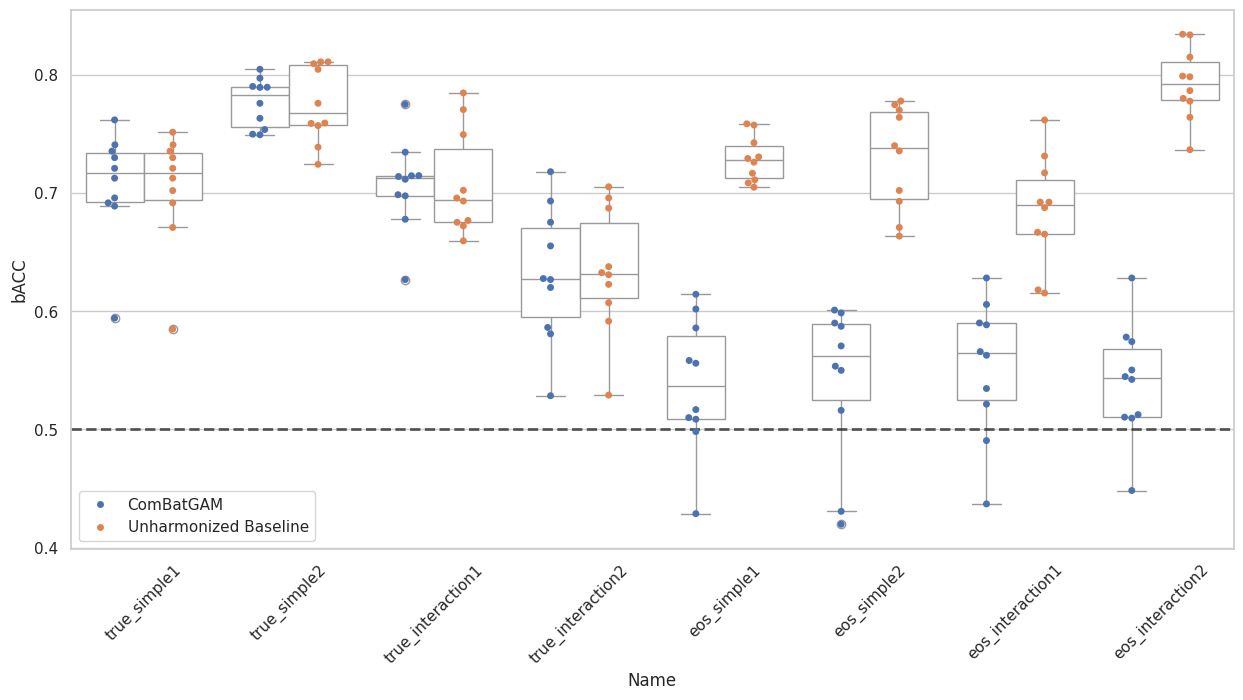

In [7]:
# %% Plotting results
fig, ax = plt.subplots(1, 1, figsize=[15, 7])

harm_methods = [
    "ComBatGAM",
    "Unharmonized Baseline",
]

sns.swarmplot(data=results, x="Name", y="bACC", hue="Method", hue_order=harm_methods, dodge=True, ax=ax)

sns.boxplot(
    data=results,
    color="w",
    zorder=1,
    x="Name",
    y="bACC",
    hue="Method",
    hue_order=harm_methods,
    dodge=True,
    ax=ax,
    palette=["w"] * len(harm_methods),
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[: len(harm_methods)], labels[: len(harm_methods)])
ax.axhline(0.5, lw=2, color="k", ls="--", alpha=0.7, label="Chance level")
plt.grid(axis="y")
plt.grid(axis="y")
plt.xticks(rotation=45)

plt.show()
# %%

## 6) Take-home message
- The final markdown note states:
    - `ComBatGAM` removes the `eos` site effect while preserving the `true` signal.
- The plot and results demonstrate the method’s ability to reduce spurious site-related variation and maintain true biological effect performance.